<a id="section-top"></a>
# Table of Contents
* [Introduction](#section-intro)
* [1. Basic Processing, Data Preparation](#section-one)
* [2. Visualizing Images](#section-two)
* [3. Simple Model](#section-three)
* [4. Simple Model with Data Augmentation](#section-four)
    * [4.1 Data Augmentation](#section-four-one)
    * [4.2 Feed Model with Augmented Data](#section-four-two)


* [5. Adding few Layers](#section-five)
* [6. Final Model](#section-six)
* [7. Interpreting Results and Error Analysis](#section-seven)
    * [7.1 Confusion Matrix](#section-seven-one)
    * [7.2 Error Analysis](#section-seven-two)



* [Conclusion](#section-conc)
* [Readings, Resources](#section-read)

<a id="section-intro"></a>
# Introduction
In this notebook, I will build a CNN network layer by layer. Visualize observations and results. Try something and see results. It is deep learning, enjoy it.

In [1]:
import os
import random
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

import tensorflow as tf
from keras.utils.vis_utils import plot_model
from keras.utils.np_utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Dropout, Flatten, BatchNormalization
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [2]:
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
len(tf.config.list_physical_devices('GPU'))

2021-11-11 00:26:02.842115: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-11 00:26:02.955316: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-11 00:26:02.956299: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


1

Setting seed for reproducibility

https://www.kaggle.com/lbronchal/keras-gpu-cpu-reproducibility-test

In [3]:
seed = 666
tf.random.set_seed(seed)
np.random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)                      
random.seed(666)

[take me to the top](#section-top)

<a id="section-one"></a>

# 1. Basic Processing, Data Preparation

In [4]:
train = pd.read_csv("../input/digit-recognizer/train.csv")
test = pd.read_csv("../input/digit-recognizer/test.csv")

print(f"Training observations {train.shape[0]}, Test observations {test.shape[0]} \n")

train.head()

Training observations 42000, Test observations 28000 



,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We have quitely balanced dataset, nice.

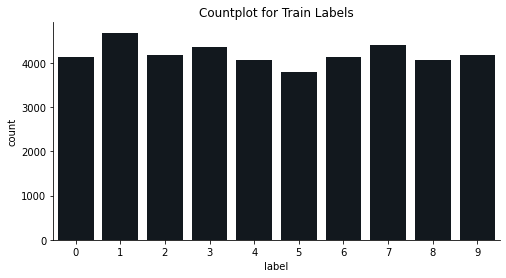

In [5]:
fig, ax = plt.subplots(figsize = (8, 4))

sns.countplot(data = train, x = "label", ax = ax, color = "#101820")

ax.set_title("Countplot for Train Labels")

sns.despine()
plt.show()

In [6]:
train_X = train.drop("label", axis = 1)
train_y = train["label"]

del train
_ = gc.collect()

Converting images to gray scale. It helps to converge CNN quickly.

In [7]:
train_X = train_X / 255
X_test = test / 255

del test
_ = gc.collect()

We have 784 pixel data, it means 28*28 pixel images.

In [8]:
print(f"Training data shape: {train_X.shape} \nTest data shape: {X_test.shape}")

train_X = train_X.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)

print(f"Training data shape after rescaling: {train_X.shape} \nTest data shape after rescaling: {X_test.shape}")

Training data shape: (42000, 784) 
Test data shape: (28000, 784)
Training data shape after rescaling: (42000, 28, 28, 1) 
Test data shape after rescaling: (28000, 28, 28, 1)


Converting label to one hot vectors.

In [9]:
train_y = to_categorical(train_y, num_classes = 10)

You can see 100 images from training set from below.

[take me to the top](#section-top)

<a id="section-two"></a>

# 2. Visualizing Images

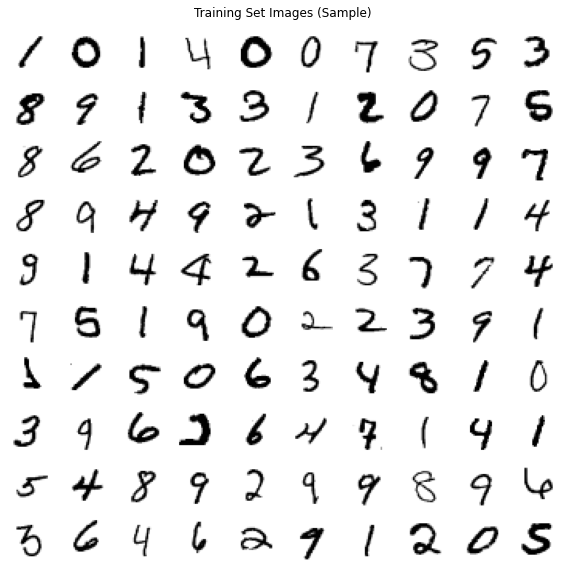

In [10]:
fig = plt.figure(1, figsize = (8, 8))
fig.suptitle("Training Set Images (Sample)")

for i in range(100):
    
    plt.subplot(10, 10, i + 1)
    plt.imshow(train_X[i], cmap = plt.cm.binary)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

You can see 100 images from test set from below. A couple of them is really hard to detectable, isn't it?

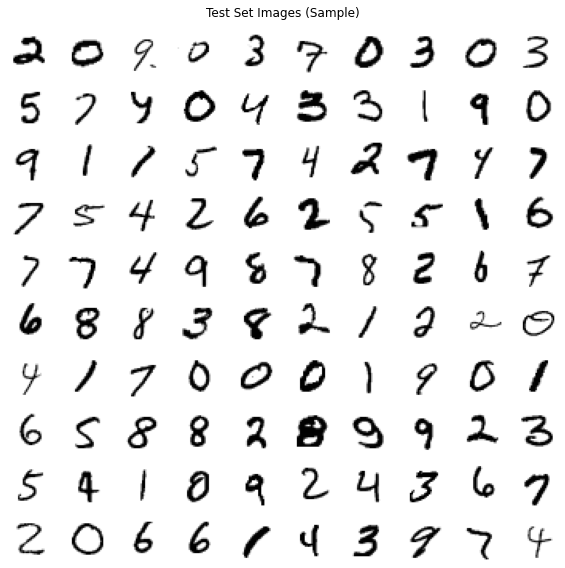

In [11]:
fig = plt.figure(1, figsize = (8, 8))
fig.suptitle("Test Set Images (Sample)")

for i in range(100):
    
    plt.subplot(10, 10, i + 1)
    plt.imshow(X_test[i], cmap = plt.cm.binary)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

Creating validation set with 10% of training data. It is enough.

I also set stratify parameter for equally distributed labels.

[take me to the top](#section-top)

<a id="section-three"></a>

# 3. Simple Model

In [12]:
X_train, X_val, y_train, y_val = train_test_split(train_X, 
                                                  train_y, 
                                                  test_size = 0.1, 
                                                  random_state = 666, 
                                                  stratify = train_y)

print(f"Training set shape: {X_train.shape} \nValidation set shape: {X_val.shape}")

Training set shape: (37800, 28, 28, 1) 
Validation set shape: (4200, 28, 28, 1)


First, I will create a simple CNN model to see what we need. After looking first results, I will add some layers or doing something.

For first model, I will just use two convolutional layer with 32 filter, 3 kernel size with relu activation. Then, max pooling with (2, 2) pool size.

In [13]:
def simple_model():
    
    model = Sequential(
        [
            Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu", input_shape = (28, 28, 1)),
            Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu"),
            MaxPool2D(pool_size = (2, 2)),
            
            Flatten(),
            Dense(units = 10, activation = "softmax")
        ]
    )
    
    model.compile(loss = "categorical_crossentropy", metrics = "accuracy", optimizer = "adam")
    
    return model

In [14]:
model = simple_model()
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 4608)              0         
_________________________________________________________________
dense (Dense)                (None, 10)                46090     
Total params: 55,658
Trainable params: 55,658
Non-trainable params: 0
_________________________________________________________________


2021-11-11 00:26:20.046732: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2021-11-11 00:26:20.048124: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-11 00:26:20.048894: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-11-11 00:26:20.049571: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA 

Simple Model Architecture



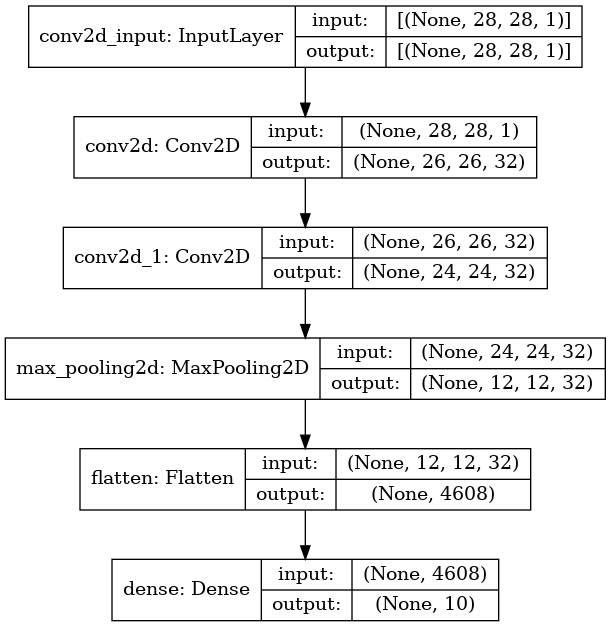

In [15]:
print("Simple Model Architecture\n")
plot_model(model, to_file = "simple_model.png", show_shapes = True, show_layer_names = True)

In [16]:
history = model.fit(
    X_train, y_train, 
    validation_data = (X_val, y_val),
    epochs = 10, batch_size = 64
)

2021-11-11 00:26:23.550609: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/10


2021-11-11 00:26:24.769183: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


591/591 [==============================] - 9s 4ms/step - loss: 0.2322 - accuracy: 0.9325 - val_loss: 0.0976 - val_accuracy: 0.9705
Epoch 2/10
591/591 [==============================] - 2s 4ms/step - loss: 0.0679 - accuracy: 0.9798 - val_loss: 0.0598 - val_accuracy: 0.9810
Epoch 3/10
591/591 [==============================] - 2s 4ms/step - loss: 0.0478 - accuracy: 0.9856 - val_loss: 0.0623 - val_accuracy: 0.9831
Epoch 4/10
591/591 [==============================] - 2s 4ms/step - loss: 0.0360 - accuracy: 0.9893 - val_loss: 0.0634 - val_accuracy: 0.9817
Epoch 5/10
591/591 [==============================] - 2s 4ms/step - loss: 0.0286 - accuracy: 0.9909 - val_loss: 0.0721 - val_accuracy: 0.9805
Epoch 6/10
591/591 [==============================] - 3s 4ms/step - loss: 0.0226 - accuracy: 0.9925 - val_loss: 0.0622 - val_accuracy: 0.9838
Epoch 7/10
591/591 [==============================] - 2s 4ms/step - loss: 0.0171 - accuracy: 0.9946 - val_loss: 0.0772 - val_accuracy: 0.9810
Epoch 8/10
591/59

Okay, we have overfitting situation. We have high balance. To solve it, we can get more data. Data augmentation is one of the most important techniques for this situation, since we are working on image data.

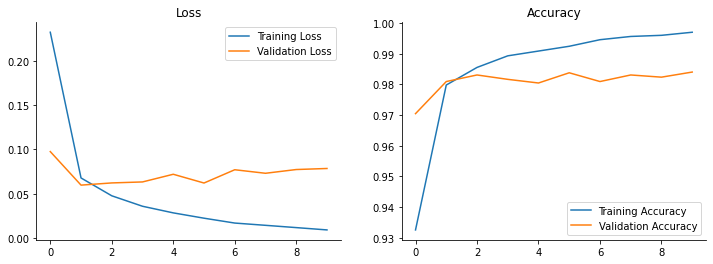

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.lineplot(x = range(10), y = history.history["loss"], ax = axes[0], label = "Training Loss")
sns.lineplot(x = range(10), y = history.history["val_loss"], ax = axes[0], label = "Validation Loss")

sns.lineplot(x = range(10), y = history.history["accuracy"], ax = axes[1], label = "Training Accuracy")
sns.lineplot(x = range(10), y = history.history["val_accuracy"], ax = axes[1], label = "Validation Accuracy")
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")

sns.despine()
plt.show()

We can create new images with using ImageDataGenerator class from Keras.

It takes an image, rotates, shifts, zooms etc.

But we have to be careful. We are working with number images and some augmentations could hurt our model. For example, if we use flipping, we get meaningles images, and for some numbers i.e. 6 and 9, it will cause a problem.

[take me to the top](#section-top)

<a id="section-four"></a>

# 4. Simple Model with Data Augmentation

<a id="section-four-one"></a>

## 4.1 Data Augmentation

In [18]:
datagen = ImageDataGenerator(
    rotation_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.15,
    horizontal_flip = False, 
    vertical_flip = False
)

At the top, we can see a random original image from training set.

At the bottom, we have its 30 copies with some rotation, shifting, etc.

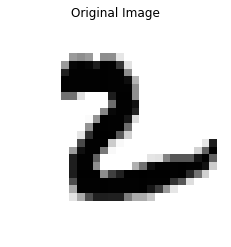

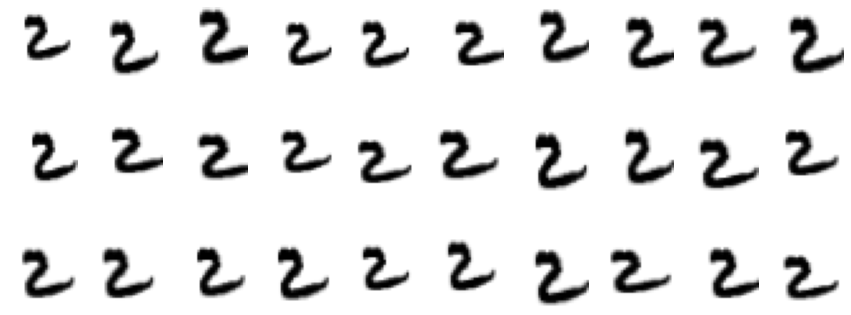

In [19]:
sample_image = 12345

plt.imshow(X_train[sample_image], cmap = plt.cm.binary)
plt.title("Original Image")
plt.axis("off"); plt.show()

aug = datagen.flow(X_train[sample_image].reshape(-1, 28, 28, 1), batch_size = 1)

fig, axes = plt.subplots(3, 10, figsize = (15, 6))
axes = axes.ravel()

for i in range(30):  
    
    aug_img = next(aug)[0]
    axes[i].imshow(aug_img, cmap = plt.cm.binary)
    axes[i].axis("off")
    
plt.show()

<a id="section-four-two"></a>

## 4.2 Feed Model with Augmented Data

In [20]:
del model

_ = gc.collect()
tf.keras.backend.clear_session()

model = simple_model()

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 4608)              0         
_________________________________________________________________
dense (Dense)                (None, 10)                46090     
Total params: 55,658
Trainable params: 55,658
Non-trainable params: 0
_________________________________________________________________


Now, I will use same model with augmented dataset. Let's examine it and then see what we will do.

In [21]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size = 64),
    epochs = 10, validation_data = (X_val, y_val),
    steps_per_epoch = X_train.shape[0] // 64
)

Epoch 1/10
590/590 [==============================] - 12s 20ms/step - loss: 0.4860 - accuracy: 0.8493 - val_loss: 0.1106 - val_accuracy: 0.9705
Epoch 2/10
590/590 [==============================] - 12s 20ms/step - loss: 0.1916 - accuracy: 0.9433 - val_loss: 0.0874 - val_accuracy: 0.9769
Epoch 3/10
590/590 [==============================] - 12s 20ms/step - loss: 0.1441 - accuracy: 0.9562 - val_loss: 0.0787 - val_accuracy: 0.9767
Epoch 4/10
590/590 [==============================] - 12s 20ms/step - loss: 0.1247 - accuracy: 0.9630 - val_loss: 0.0631 - val_accuracy: 0.9831
Epoch 5/10
590/590 [==============================] - 13s 22ms/step - loss: 0.1090 - accuracy: 0.9673 - val_loss: 0.0620 - val_accuracy: 0.9824
Epoch 6/10
590/590 [==============================] - 12s 20ms/step - loss: 0.0964 - accuracy: 0.9716 - val_loss: 0.0612 - val_accuracy: 0.9805
Epoch 7/10
590/590 [==============================] - 12s 21ms/step - loss: 0.0910 - accuracy: 0.9730 - val_loss: 0.0579 - val_accuracy:

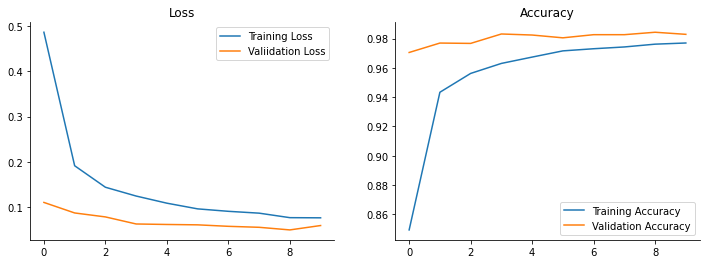

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.lineplot(x = range(10), y = history.history["loss"], ax = axes[0], label = "Training Loss")
sns.lineplot(x = range(10), y = history.history["val_loss"], ax = axes[0], label = "Valiidation Loss")

sns.lineplot(x = range(10), y = history.history["accuracy"], ax = axes[1], label = "Training Accuracy")
sns.lineplot(x = range(10), y = history.history["val_accuracy"], ax = axes[1], label = "Validation Accuracy")
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")

sns.despine()
plt.show()

Okay, our model didn't learn well, high bias. We use 10 epochs, we can increase that. Or, We can create bigger network and then we will look at what did happened.

I just add 2 convolutional layer with 64 filters, max pooling again and 0.3 dropout. We still have a simple model.

[take me to the top](#section-top)

<a id="section-five"></a>

# 5. Adding few Layers

In [23]:
def simple_extra_layers():

    model = Sequential(
        [
            Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu", input_shape = (28, 28, 1)),
            Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu"),
            MaxPool2D(pool_size = (2, 2)),

            Conv2D(filters = 64, kernel_size = (3, 3), activation = "relu"),
            Conv2D(filters = 64, kernel_size = (3, 3), activation = "relu"),
            MaxPool2D(pool_size = (2, 2)),   
            Dropout(0.3),

            Flatten(),
            Dense(units = 10, activation = "softmax")
        ]
    )

    model.compile(loss = "categorical_crossentropy", metrics = "accuracy", optimizer = "adam")
    
    return model

In [24]:
del model

_ = gc.collect()
tf.keras.backend.clear_session()

model = simple_extra_layers()

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 10, 10, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 8, 8, 64)          36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 4, 4, 64)          0         
_________________________________________________________________
dropout (Dropout)            (None, 4, 4, 64)          0

Adding a few extra layers to Simple Model



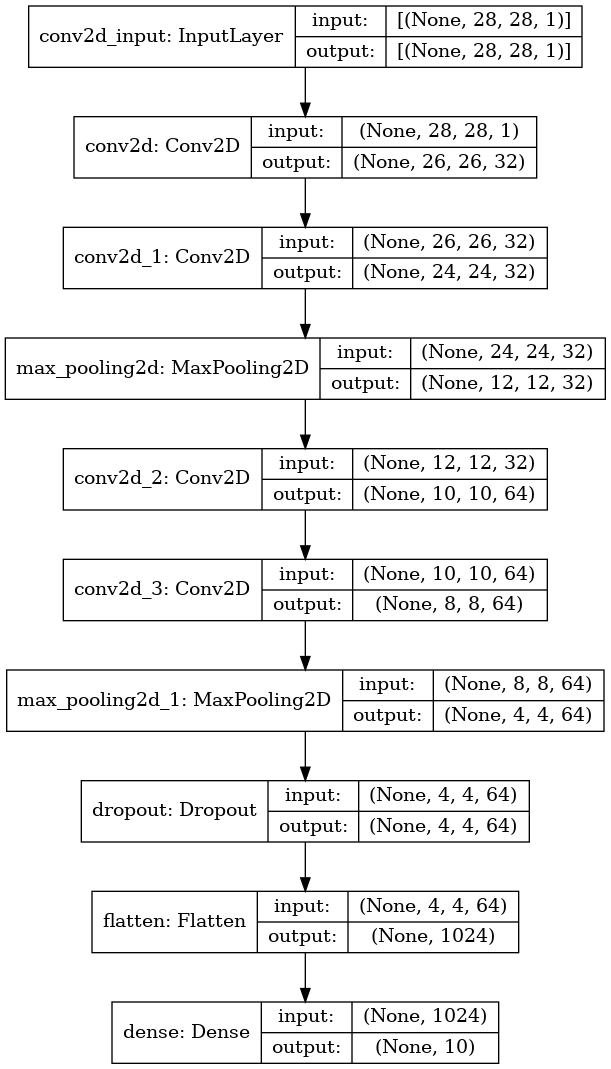

In [25]:
print("Adding a few extra layers to Simple Model\n")

plot_model(model, to_file = "few_extra_layers_model.png", show_shapes = True, show_layer_names = True)

In [26]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size = 64),
    epochs = 10, validation_data = (X_val, y_val),
    steps_per_epoch = X_train.shape[0] // 64
)

Epoch 1/10
590/590 [==============================] - 14s 22ms/step - loss: 0.4334 - accuracy: 0.8594 - val_loss: 0.0774 - val_accuracy: 0.9767
Epoch 2/10
590/590 [==============================] - 13s 22ms/step - loss: 0.1287 - accuracy: 0.9601 - val_loss: 0.0483 - val_accuracy: 0.9862
Epoch 3/10
590/590 [==============================] - 12s 20ms/step - loss: 0.0934 - accuracy: 0.9721 - val_loss: 0.0427 - val_accuracy: 0.9864
Epoch 4/10
590/590 [==============================] - 12s 21ms/step - loss: 0.0804 - accuracy: 0.9758 - val_loss: 0.0351 - val_accuracy: 0.9893
Epoch 5/10
590/590 [==============================] - 13s 21ms/step - loss: 0.0663 - accuracy: 0.9793 - val_loss: 0.0308 - val_accuracy: 0.9898
Epoch 6/10
590/590 [==============================] - 12s 21ms/step - loss: 0.0611 - accuracy: 0.9814 - val_loss: 0.0347 - val_accuracy: 0.9907
Epoch 7/10
590/590 [==============================] - 12s 21ms/step - loss: 0.0540 - accuracy: 0.9832 - val_loss: 0.0344 - val_accuracy:

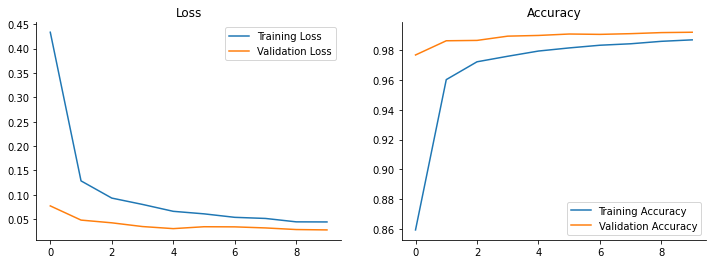

In [27]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.lineplot(x = range(len(history.history["loss"])), y = history.history["loss"], ax = axes[0], label = "Training Loss")
sns.lineplot(x = range(len(history.history["loss"])), y = history.history["val_loss"], ax = axes[0], label = "Validation Loss")

sns.lineplot(x = range(len(history.history["accuracy"])), y = history.history["accuracy"], ax = axes[1], label = "Training Accuracy")
sns.lineplot(x = range(len(history.history["accuracy"])), y = history.history["val_accuracy"], ax = axes[1], label = "Validation Accuracy")
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")

sns.despine()
plt.show()

High bias problem remains. If we increase epoch number, this problem could be solved. Or adding more layers, for example Batch Normalization can be helpful for converging faster.

[take me to the top](#section-top)

<a id="section-six"></a>

# 6. Final Model

I just add BatchNormalization after convolutional layers and also, two fully connected layers (128 - 64 units) with batch normalization added before the output layer.

In [28]:
def final_model():

    model = Sequential(
        [
            Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu", input_shape = (28, 28, 1)),
            BatchNormalization(),
            Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu"),
            BatchNormalization(),
            MaxPool2D(pool_size = (2, 2)),

            Conv2D(filters = 64, kernel_size = (3, 3), activation = "relu"),
            BatchNormalization(),
            Conv2D(filters = 64, kernel_size = (3, 3), activation = "relu"),
            BatchNormalization(),
            MaxPool2D(pool_size = (2, 2)),   
            Dropout(0.3),
            
            Flatten(),
            Dense(units = 128, activation = "relu"),
            BatchNormalization(),
            Dense(units = 64, activation = "relu"),
            BatchNormalization(),
            Dense(units = 10, activation = "softmax")
        ]
    )

    model.compile(loss = "categorical_crossentropy", metrics = "accuracy", optimizer = "adam")
    
    return model

In [29]:
del model

_ = gc.collect()
tf.keras.backend.clear_session()

model = final_model()
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
batch_normalization (BatchNo (None, 26, 26, 32)        128       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
batch_normalization_1 (Batch (None, 24, 24, 32)        128       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 10, 10, 64)        18496     
_________________________________________________________________
batch_normalization_2 (Batch (None, 10, 10, 64)        2

Final Model Archtitecture



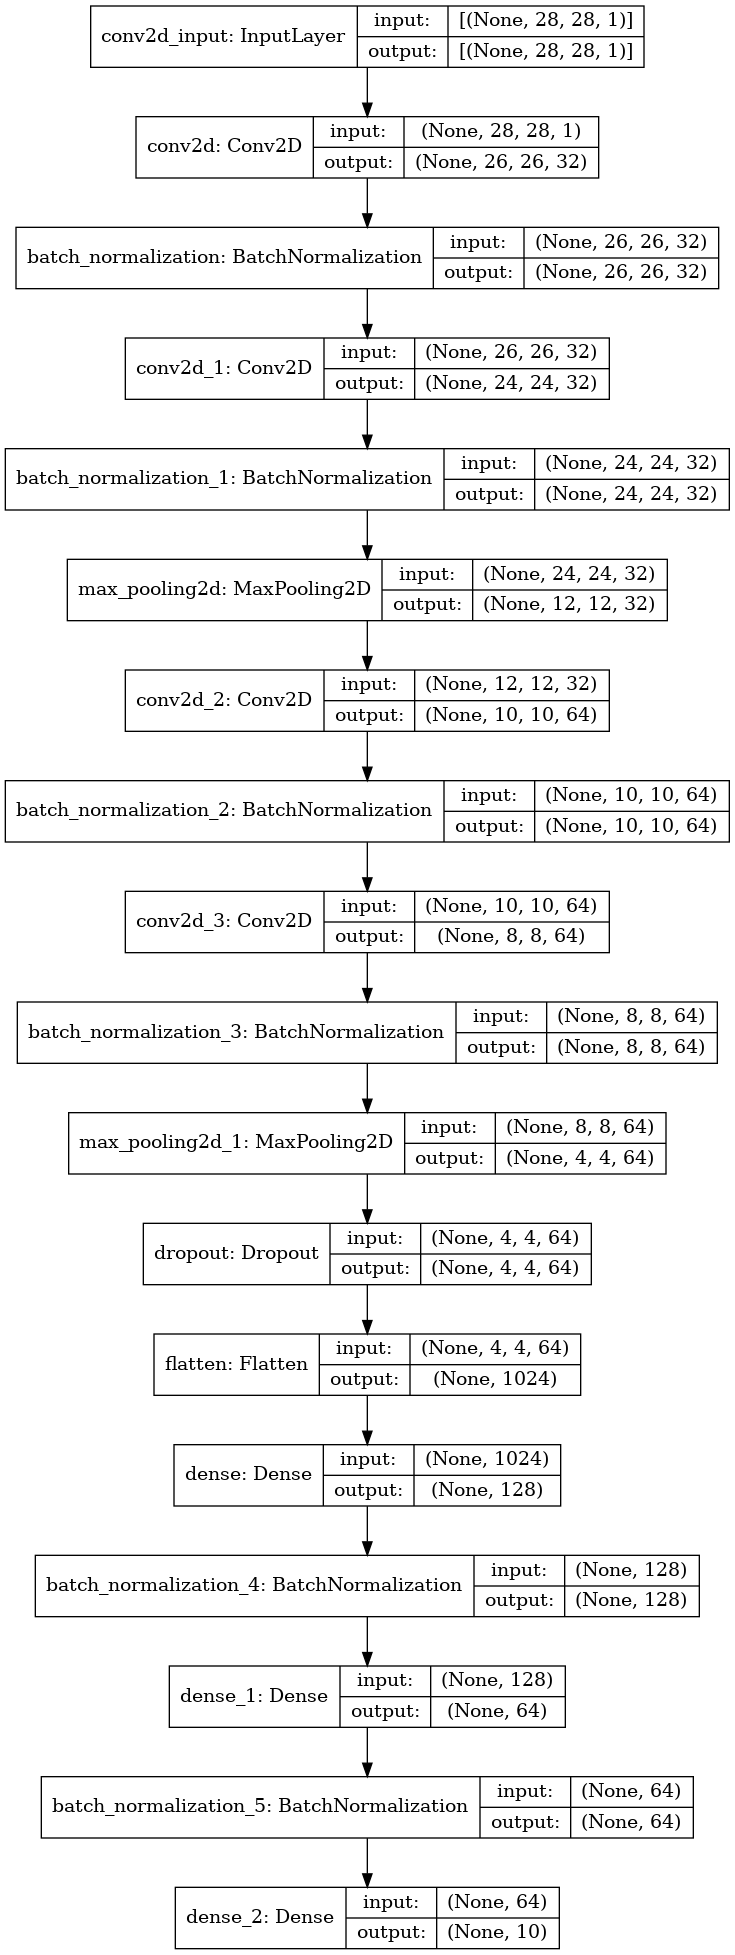

In [30]:
print("Final Model Archtitecture\n")

plot_model(model, to_file = "final_model.png", show_shapes = True, show_layer_names = True)

If we use more epochs, some callbacks will help us to prevent overfitting problem.

ReduceLROnPPlateau, reduces learning rate during training. It monitors a metric or loss, if results are not going well, it reduces learning rate.

EarlyStopping, stops training if validation score doesn't improve. Important for prevent overfitting.

Checkpoint, saves model when validation score improves.

In [31]:
reduce_lr = ReduceLROnPlateau(
    monitor = "val_accuracy", 
    patience = 3,
    verbose = 1, 
    factor = 0.5, 
    min_lr = 0.0000001
)

early_stopping = EarlyStopping(
    monitor = "val_accuracy",
    patience = 10,
    verbose = 1,
    mode = "max",
)

checkpoint = ModelCheckpoint(
    monitor = "val_accuracy",
    filepath = "mnist_cnn.{epoch:02d}-{val_accuracy:.6f}.hdf5",
    verbose = 1,
    save_best_only = True, 
    save_weights_only = True
)

In [32]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size = 64),
    epochs = 100, batch_size = 64, validation_data = (X_val, y_val),
    steps_per_epoch = X_train.shape[0] // 64,
    callbacks=[reduce_lr, early_stopping, checkpoint]
)

Epoch 1/100
590/590 [==============================] - 14s 23ms/step - loss: 0.3093 - accuracy: 0.9083 - val_loss: 0.0741 - val_accuracy: 0.9788

Epoch 00001: val_accuracy improved from -inf to 0.97881, saving model to mnist_cnn.01-0.978810.hdf5
Epoch 2/100
590/590 [==============================] - 14s 24ms/step - loss: 0.0927 - accuracy: 0.9711 - val_loss: 0.0411 - val_accuracy: 0.9876

Epoch 00002: val_accuracy improved from 0.97881 to 0.98762, saving model to mnist_cnn.02-0.987619.hdf5
Epoch 3/100
590/590 [==============================] - 13s 22ms/step - loss: 0.0717 - accuracy: 0.9775 - val_loss: 0.0367 - val_accuracy: 0.9895

Epoch 00003: val_accuracy improved from 0.98762 to 0.98952, saving model to mnist_cnn.03-0.989524.hdf5
Epoch 4/100
590/590 [==============================] - 14s 23ms/step - loss: 0.0613 - accuracy: 0.9813 - val_loss: 0.0315 - val_accuracy: 0.9914

Epoch 00004: val_accuracy improved from 0.98952 to 0.99143, saving model to mnist_cnn.04-0.991429.hdf5
Epoch 5

In [33]:
del model

_ = gc.collect()
tf.keras.backend.clear_session()

model = final_model()
model.load_weights("./mnist_cnn.24-0.996429.hdf5")

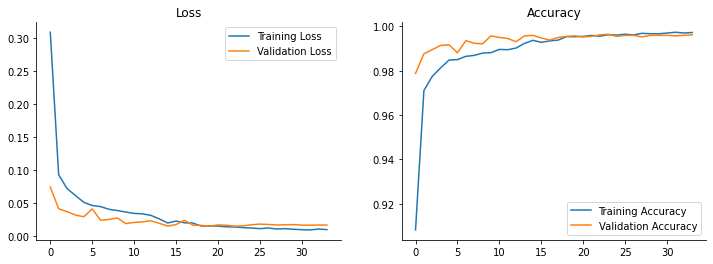

In [34]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.lineplot(x = range(len(history.history["loss"])), y = history.history["loss"], ax = axes[0], label = "Training Loss")
sns.lineplot(x = range(len(history.history["loss"])), y = history.history["val_loss"], ax = axes[0], label = "Validation Loss")

sns.lineplot(x = range(len(history.history["accuracy"])), y = history.history["accuracy"], ax = axes[1], label = "Training Accuracy")
sns.lineplot(x = range(len(history.history["accuracy"])), y = history.history["val_accuracy"], ax = axes[1], label = "Validation Accuracy")
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")

sns.despine()
plt.show()

Nice, there is no problem. But now, let's look at the predictions.

[take me to the top](#section-top)

<a id="section-seven"></a>

# 7. Interpreting Results and Error Analysis

In [35]:
val_preds = np.argmax(model.predict(X_val), axis = 1)
train_preds = np.argmax(model.predict(X_train), axis = 1)

<a id="section-seven-one"></a>

## 7.1 Confusion Matrix

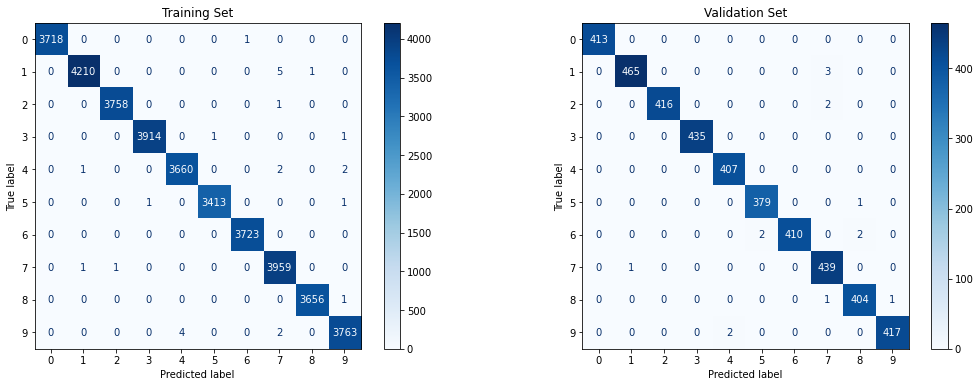

In [36]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

cm_train = confusion_matrix(np.argmax(y_train, axis = 1), train_preds)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_train)
disp.plot(cmap = plt.cm.Blues, ax = axes[0])

cm_val = confusion_matrix(np.argmax(y_val, axis = 1), val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_val)
disp.plot(cmap = plt.cm.Blues, ax = axes[1])

axes[0].set_title("Training Set"); axes[1].set_title("Validation Set")

plt.show()

Let's look at confusion matrix. Two things are noticeable. There is a confusion between 4-9 and 1-7.

We can see this problem both sets. 

One more thing. I want to know how the model fails at 4-9. Let's look at images that the model predict wrong.

[take me to the top](#section-top)

<a id="section-seven-two"></a>

## 7.2 Error Analysis

In [37]:
errors = (val_preds - np.argmax(y_val, axis = 1) != 0)

pred_error = val_preds[errors]
observed_error = np.argmax(y_val, axis = 1)[errors]
image_error = X_val[errors]
len(pred_error)

15

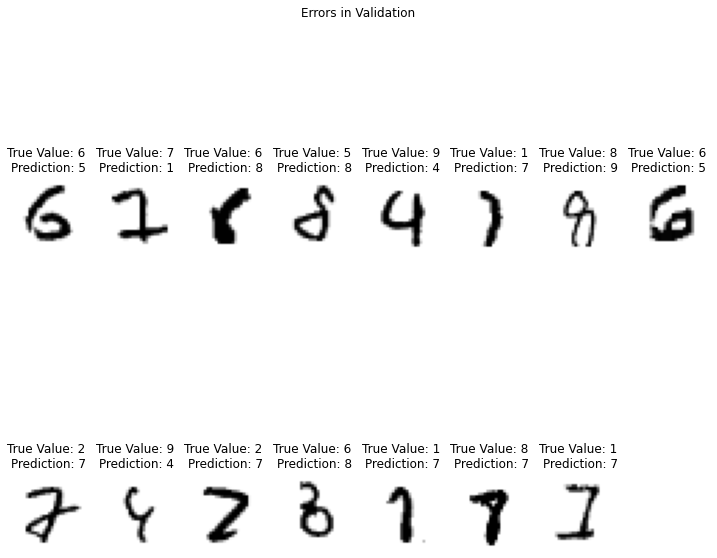

In [38]:
fig = plt.figure(1, figsize=(10, 10))
fig.suptitle("Errors in Validation")

rows = int(len(pred_error) ** 0.5) - 1
cols = int(len(pred_error) / rows) + 1

for i in range(len(pred_error)):
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image_error[i], cmap = plt.cm.binary)
    plt.axis("off")
    plt.title(f"True Value: {observed_error[i]} \nPrediction: {pred_error[i]}")
    
plt.tight_layout()
plt.show()

In [39]:
errors = (train_preds - np.argmax(y_train, axis = 1) != 0)

train_pred_error = train_preds[errors]
train_observed_error = np.argmax(y_train, axis = 1)[errors]
train_image_error = X_train[errors]
len(train_pred_error)

26

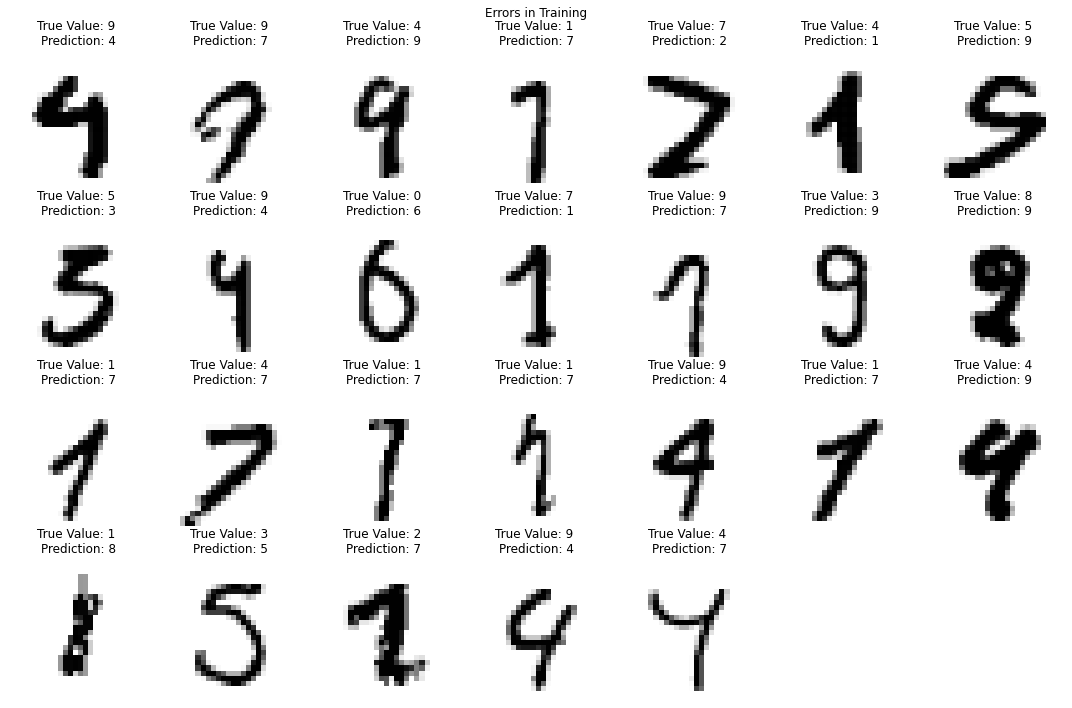

In [40]:
fig = plt.figure(1, figsize = (15, 10))
fig.suptitle("Errors in Training")

rows = int(len(train_pred_error) ** 0.5) - 1
cols = int(len(train_pred_error) / rows) + 1

for i in range(len(train_pred_error)):
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(train_image_error[i], cmap = plt.cm.binary)
    plt.axis("off")
    plt.title(f"True Value: {train_observed_error[i]} \nPrediction: {train_pred_error[i]}")
    
plt.tight_layout()
plt.show()

Hard to detect for human eyes.

[take me to the top](#section-top)

In [41]:
submission = pd.read_csv("../input/digit-recognizer/sample_submission.csv")

preds = np.argmax(model.predict(X_test), axis = 1)
submission["Label"] = preds
submission.to_csv("cnn.csv",index = False)
submission

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


[take me to the top](#section-top)

<a id="section-conc"></a>

# Conclusion

In machine learning - deep learning, I think, the most important think is to know what you do. If you have knowledge about how they work, you can code it without much effort. Try lots of things, fail, add or change something, fail, try different idea, fail. Finally, you can success.

It is like a computer game.

[take me to the top](#section-top)

<a id="section-read"></a>

# Readings, Resources

https://www.kaggle.com/yassineghouzam/introduction-to-cnn-keras-0-997-top-6?rvi=1

https://www.kaggle.com/cdeotte/25-million-images-0-99757-mnist

https://www.kaggle.com/lbronchal/keras-gpu-cpu-reproducibility-test


Andrew NG's Deep Learning course is as good as his Machine Learning course. If you need theory, you should look at it.

https://keras.io/examples/vision/

Finally, I want to say that, Keras has one of the best documentations that I read. You should take a look at. It will motivate you.

[take me to the top](#section-top)